# Approximating the reverse causal cone with a Tree Tensor Network

For a depth-$p$ QAOA circuit, $\langle Z_iZ_j\rangle$ for an edge $(i,j)$ only depends on its **reverse causal cone**: the sub-circuit built from graph edges within distance $p$ of $i$ or $j$ (this is what `LightConeEvaluator` already exploits, via exact statevector simulation of the reduced circuit).

**Key fact**: if the graph's girth is large enough relative to $p$, this causal-cone subgraph is itself a *tree*. It can then be represented directly as a Tree Tensor Network (TTN) whose topology matches the causal cone -- every QAOA gate acts on tree-adjacent qubits, so no SWAP routing is needed. Bounding the TTN bond dimension $\chi$ gives a controlled approximation of $\langle Z_iZ_j\rangle$.

**When the cone is not a tree** (short cycles, dense instances, larger $p$) the TTN topology can no longer match the cone exactly. We keep the TTN and *route*: the TTN is built on a BFS spanning tree of the cone, and every cone edge that closes a cycle is implemented by SWAPping one of its two qubits along the tree path until the pair is tree-adjacent, applying the RZZ there, and undoing the SWAPs. This is the standard trick used for MPS circuit simulation (`MPSEvaluator`'s `use_swap_strategy`), transplanted onto a tree instead of a line, and it keeps the evaluator a TTN evaluator on every instance rather than silently degrading to statevector simulation.

We use [pytreenet](https://github.com/Drachier/PyTreeNet)'s low-level TTN primitives (`contract_nodes` + `absorb_into_open_legs` + `split_node_svd`), the same building blocks pytreenet's own TEBD implementation uses to apply a two-site gate and truncate back down. It is not a dependency of this repository, so install it first: `pip install pytreenet`.

In [1]:
import glob
import json
import time

import networkx as nx
import numpy as np
import pytreenet as ptn
from scipy.linalg import expm

from qaoa_training_pipeline.evaluation.light_cone import LightConeEvaluator
from qaoa_training_pipeline.evaluation.mps_evaluator import MPSEvaluator
from qaoa_training_pipeline.evaluation.efficient_depth_one import EfficientDepthOneEvaluator
from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.training.fixed_angle_conjecture import FixedAngleConjecture
from qaoa_training_pipeline.utils.graph_utils import (
    graph_to_operator,
    load_graph,
    operator_to_graph,
    operator_to_list_of_hyper_edges,
)

X, _, Z = ptn.pauli_matrices()

## TTN causal-cone evaluator

`causal_cone_energy` builds the causal cone of a single edge (reusing `LightConeEvaluator.make_radius_edges`), lays a `|+>`-product TTN on a **BFS spanning tree** of that cone, applies the QAOA layers with bond dimension `max_bond_dim`, and reads off `<Z_iZ_j>`. `ttn_causal_cone_evaluate` sums this over all edges to get the QAOA energy.

Three details make the non-tree case work:

* **Topology.** The spanning tree is grown by BFS from `edge[0]`. Since `edge[1]` is then discovered directly from the root, the measured edge is always tree-local, and the tree stays as shallow as the cone allows -- which is what keeps the routing paths short.
* **Routing.** Cone edges that are not tree edges (the *chords*, one per independent cycle) are applied by `apply_rzz`: it walks the unique tree path between the two qubits, SWAPs one of them along it until the pair sits on adjacent TTN sites, applies the RZZ there, and then replays the SWAPs backwards. Undoing the routing restores the qubit-to-site map, so the BFS layout -- which is optimal for the many tree edges -- is the layout every gate starts from. `site_of` / `qubit_at` track the (temporary) permutation, and the tree paths are cached since the map is back to the identity by the time the next gate is applied.
* **Truncation.** Every two-site gate, SWAPs included, is followed by a truncated SVD back to `max_bond_dim`. On a tree cone the SWAPs never fire and $\chi$ only has to cover the cone's own entanglement; with chords present the SWAPs themselves generate entanglement, so $\chi$ becomes the real accuracy knob. That makes it worth paying for a *correct* truncation: unlike pytreenet's TEBD, which splits the pair wherever the state happens to be, we keep an orthogonality center and move it onto the pair before each gate, so the discarded singular values really are the smallest Schmidt coefficients. On the line-based instances below that costs about $1.5\times$ the runtime and buys between a factor of two and an order of magnitude in accuracy at fixed $\chi$ (the denser the cone, the more of the error is genuine truncation that no amount of care can undo).

In [2]:
# SWAP with the leg order `absorb_into_open_legs` expects after `contract_nodes(id1, id2)`,
# i.e. (out1, out2, in1, in2). SWAP and RZZ are both symmetric under exchanging the two
# qubits, so the two sites may be passed in either order.
SWAP = np.eye(4, dtype=complex)[[0, 2, 1, 3]].reshape(2, 2, 2, 2)


def causal_cone_energy(graph, edge, betas, gammas, max_bond_dim):
    """<Z_i Z_j> for `edge`, approximated via a bond-dimension-limited TTN of its causal cone."""
    lce = LightConeEvaluator()
    lce.graph = graph
    depth = len(betas)
    cone_edges = lce.make_radius_edges(edge, radius=depth)

    cone = nx.Graph()
    cone.add_edges_from((u, v, {"weight": w}) for (u, v), w in cone_edges.items())
    if not cone.has_edge(*edge):
        cone.add_edge(*edge, weight=graph[edge[0]][edge[1]].get("weight", 1.0))

    # The TTN topology is a BFS spanning tree of the cone rooted at `edge[0]`. On a tree cone
    # this is the cone itself; otherwise the cone edges left out (the chords) are the ones that
    # will need SWAP routing below. Rooting at `edge[0]` puts `edge[1]` one hop away, so the
    # measured correlator is always tree-local.
    root = edge[0]
    tree = nx.Graph(nx.bfs_tree(cone, root))

    # Build a |+>-product TTN whose topology is exactly that spanning tree.
    degree = dict(tree.degree)
    plus_tensor = lambda n_neighbours: np.full((1,) * n_neighbours + (2,), 1 / np.sqrt(2), dtype=complex)

    ttn = ptn.TreeTensorNetworkState()
    ttn.add_root(ptn.Node(identifier=str(root)), plus_tensor(degree[root]))
    next_free_slot = {root: 0}  # next unused neighbour-leg on each node already in the TTN
    for parent, child in nx.bfs_edges(tree, root):
        ttn.add_child_to_parent(
            ptn.Node(identifier=str(child)), plus_tensor(degree[child]),
            0, str(parent), next_free_slot[parent],
        )
        next_free_slot[parent] += 1
        next_free_slot[child] = 1  # leg 0 of the child is now taken by its parent

    ttn.canonical_form(str(root))
    svd_params = ptn.SVDParameters(max_bond_dim=max_bond_dim, rel_tol=0.0, total_tol=1e-14)

    # Routing bookkeeping: `site_of[q]` is the TTN site currently holding qubit `q`, and
    # `qubit_at` is its inverse. Both start out as the identity and are restored to it after
    # every routed gate, which is why the tree paths can be cached across QAOA layers.
    site_of = {qubit: qubit for qubit in tree}
    qubit_at = {site: site for site in tree}
    routing_paths = {}

    def apply_two_site_gate(site1, site2, gate):
        # Same 4-step pattern pytreenet's TEBD uses to apply+truncate a nearest-neighbour gate,
        # plus the orthogonality-center bookkeeping that makes the truncation optimal.
        id1, id2 = str(site1), str(site2)
        ttn.move_orthogonalization_center(id1)
        u_legs, v_legs = ttn.legs_before_combination(id1, id2)
        ttn.contract_nodes(id1, id2, new_identifier="contr")
        ttn.absorb_into_open_legs("contr", gate)
        ttn.split_node_svd("contr", u_legs, v_legs, u_identifier=id1, v_identifier=id2, svd_params=svd_params)
        ttn.orthogonality_center_id = id2  # `split_node_svd` absorbs the singular values into v

    def swap_sites(site1, site2):
        """Exchange the qubits held by two tree-adjacent sites."""
        apply_two_site_gate(site1, site2, SWAP)
        qubit1, qubit2 = qubit_at[site1], qubit_at[site2]
        qubit_at[site1], qubit_at[site2] = qubit2, qubit1
        site_of[qubit1], site_of[qubit2] = site2, site1

    def apply_rzz(qubit1, qubit2, gate):
        """Apply an RZZ, SWAP-routing the qubits together first if they are not tree-adjacent."""
        if (qubit1, qubit2) not in routing_paths:
            routing_paths[qubit1, qubit2] = nx.shortest_path(tree, site_of[qubit1], site_of[qubit2])
        path = routing_paths[qubit1, qubit2]

        # Walk qubit1 along the path until it is adjacent to qubit2; empty for tree edges.
        hops = list(zip(path, path[1:-1]))
        for site1, site2 in hops:
            swap_sites(site1, site2)

        apply_two_site_gate(path[-2], path[-1], gate)

        for site1, site2 in reversed(hops):  # undo the routing, restoring the BFS layout
            swap_sites(site1, site2)

    # Tree edges first, so that the SWAPs of the routed gates act on a state that already
    # carries the local correlations rather than the other way around.
    cone_edges_ordered = sorted(cone.edges(data="weight"), key=lambda e: not tree.has_edge(e[0], e[1]))

    for beta, gamma in zip(betas, gammas):
        for qubit1, qubit2, w in cone_edges_ordered:
            rzz = expm(-1j * gamma * w * np.kron(Z, Z)).reshape(2, 2, 2, 2)
            apply_rzz(qubit1, qubit2, rzz)
        # A unitary on a physical leg keeps every node an isometry, so the mixer layer leaves
        # the canonical form (and the orthogonality center) untouched.
        for site in tree:
            ttn.absorb_into_open_legs(str(site), expm(-1j * beta * X))

    zz = ttn.operator_expectation_value(
        ptn.TensorProduct({str(site_of[edge[0]]): Z, str(site_of[edge[1]]): Z})
    )
    return float(np.real(zz / ttn.scalar_product()))  # renormalize away any truncation-induced norm drift


def ttn_causal_cone_evaluate(cost_op, params, max_bond_dim):
    """QAOA energy as a sum of TTN-approximated causal-cone edge expectation values."""
    depth = len(params) // 2
    betas, gammas = params[:depth], params[depth:]
    graph = operator_to_graph(cost_op)
    return sum(
        w * causal_cone_energy(graph, (u, v), betas, gammas, max_bond_dim)
        for u, v, w in graph.edges(data="weight")
    )


def cone_routing_stats(graph, depth):
    """Per-edge causal-cone sizes and the routing effort they imply, for a whole graph.

    Returns, for every edge of `graph`, the number of qubits in its depth-`depth` cone, how
    many of the cone's edges are chords (i.e. need routing), and how many SWAPs one QAOA
    layer costs. A graph whose cones are all trees has zero chords and zero SWAPs.
    """
    lce = LightConeEvaluator()
    lce.graph = graph

    stats = []
    for edge in graph.edges:
        cone = nx.Graph(list(lce.make_radius_edges(edge, radius=depth)))
        tree = nx.Graph(nx.bfs_tree(cone, edge[0]))
        chords = [e for e in cone.edges if not tree.has_edge(*e)]
        stats.append({
            "edge": edge,
            "num_qubits": cone.number_of_nodes(),
            "num_chords": len(chords),
            # Routing a chord costs (d - 1) SWAPs to move the qubits together and as many again
            # to undo the move, with d the tree distance between its endpoints.
            "num_swaps": sum(2 * (nx.shortest_path_length(tree, u, v) - 1) for u, v in chords),
        })

    return stats

### Test: routing reproduces the exact result on cyclic cones

With `max_bond_dim` large enough that no SVD actually truncates, the routed TTN is an *exact* rewriting of the causal-cone circuit -- SWAPs and all. So it must agree with `LightConeEvaluator` (exact statevector simulation of the same cone) to machine precision, on graphs whose cones are anything but trees: triangles, squares, complete graphs, and cones that swallow the whole graph. That is the check below, at $p=1$ and $p=2$ and with random $\pm1$ weights so that the weighted RZZ angles are exercised too. A path graph is included as a control: it is a tree, so it must pass with zero SWAPs.

In [3]:
ROUTING_TESTS = {
    "C5 cycle": nx.cycle_graph(5),
    "K4 (cone = whole graph)": nx.complete_graph(4),
    "Petersen (girth 5)": nx.petersen_graph(),
    "random 3-regular, n=12": nx.random_regular_graph(3, 12, seed=1),
    "Erdos-Renyi, n=10, p=0.4": nx.gnp_random_graph(10, 0.4, seed=2),
    "path, n=8 (tree control)": nx.path_graph(8),
}

test_rng = np.random.default_rng(0)
print(f"{'graph':26s} {'p':>2s} {'qubits':>7s} {'chords':>7s} {'swaps':>7s} "
      f"{'exact':>13s} {'TTN':>13s} {'|diff|':>9s}")

for test_depth in (1, 2):
    test_params = list(test_rng.uniform(-1, 1, size=2 * test_depth))
    for name, test_graph in ROUTING_TESTS.items():
        for node1, node2 in test_graph.edges:  # random +-1 weights, as in the instances below
            test_graph[node1][node2]["weight"] = float(test_rng.choice([-1.0, 1.0]))
        test_op = graph_to_operator(test_graph, pre_factor=-0.5)

        stats = cone_routing_stats(test_graph, test_depth)
        exact = LightConeEvaluator().evaluate(test_op, test_params)
        # chi = 2^10 is far above the maximum Schmidt rank of these cones, so nothing truncates.
        routed = ttn_causal_cone_evaluate(test_op, test_params, max_bond_dim=2**10)

        assert abs(exact - routed) < 1e-9, f"{name} at p={test_depth}: {exact} != {routed}"
        print(f"{name:26s} {test_depth:2d} "
              f"{max(s['num_qubits'] for s in stats):7d} "
              f"{max(s['num_chords'] for s in stats):7d} "
              f"{max(s['num_swaps'] for s in stats):7d} "
              f"{exact:+13.9f} {routed:+13.9f} {abs(exact - routed):9.1e}", flush=True)

print("\nAll routed cones reproduce the exact statevector energy.")

graph                       p  qubits  chords   swaps         exact           TTN    |diff|
C5 cycle                    1       4       0       0  -0.884930828  -0.884930828   4.4e-16
K4 (cone = whole graph)     1       4       3       6  -1.209244582  -1.209244582   2.4e-15
Petersen (girth 5)          1       6       0       0  -2.378330466  -2.378330466   4.4e-16
random 3-regular, n=12      1       6       3      10  -2.853996559  -2.853996559   2.7e-15
Erdos-Renyi, n=10, p=0.4    1       8       4      12  -2.466807692  -2.466807692   8.9e-16
path, n=8 (tree control)    1       4       0       0  -1.259476395  -1.259476395   2.2e-16
C5 cycle                    2       5       1       6  +0.202415463  +0.202415463   5.6e-16
K4 (cone = whole graph)     2       4       3       6  +0.171998394  +0.171998394   2.2e-16
Petersen (girth 5)          2      10       6      36  +0.488824380  +0.488824380   7.8e-16
random 3-regular, n=12      2      12       7      44  +1.194645173  +1.19464517

## Validation against exact simulation

A random 5-regular graph on 100 nodes has girth 3 or 4, so at $p=1$ its cones are *not* trees and the routing is exercised on every edge. `EfficientDepthOneEvaluator` is analytically exact at $p=1$, so it plays the role of the statevector reference, which does not scale to 100 qubits. `MPSEvaluator` at the same bond dimension is shown for contrast: a random regular graph has no good one-dimensional ordering, so the line swap strategy truncates badly. (Uncomment the McGee graph -- cubic, girth 7, 24 nodes -- for a tree-cone instance where the TTN is exact up to $p=2$.)

In [4]:
# mcgee_graph = nx.LCF_graph(24, [12, 7, -7], 8)  # cubic, girth 7: tree cones up to p = 2
demo_graph = nx.random_regular_graph(5, 100, seed=0)
cost_op = graph_to_operator(demo_graph, pre_factor=-0.5)  # standard MaxCut convention

rng = np.random.default_rng(0)
depth = 1
params = rng.uniform(-1, 1, size=2 * depth)  # [beta_0, ..., beta_{p-1}, gamma_0, ..., gamma_{p-1}]

demo_stats = cone_routing_stats(demo_graph, depth)
print(f"girth {nx.girth(demo_graph)}, cones of {max(s['num_qubits'] for s in demo_stats)} qubits "
      f"with up to {max(s['num_chords'] for s in demo_stats)} chords "
      f"({max(s['num_swaps'] for s in demo_stats)} SWAPs per layer)\n")

energies, runtimes = {}, {}
for name, evaluate in {
    "TTN causal cone": lambda: ttn_causal_cone_evaluate(cost_op, params, max_bond_dim=32),
    "MPS": lambda: MPSEvaluator(bond_dim_circuit=32, use_swap_strategy=True).evaluate(cost_op, params),
    "EfficientDepthOne (exact)": lambda: EfficientDepthOneEvaluator().evaluate(cost_op, params),
}.items():
    tic = time.perf_counter()
    energies[name] = float(evaluate())
    runtimes[name] = time.perf_counter() - tic

exact_energy = energies["EfficientDepthOne (exact)"]
for name, energy in energies.items():
    print(f"{name:26s} E = {energy:14.10f}   rel. error = "
          f"{abs(energy - exact_energy) / abs(exact_energy):8.2e}   {runtimes[name]:7.2f}s")

girth 3, cones of 10 qubits with up to 6 chords (22 SWAPs per layer)



c:\Users\joely\anaconda3\envs\qaoa_pipeline\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead. `kahypar` is highly recommended for the best quality contraction paths.
  warnings.warn(
c:\Users\joely\anaconda3\envs\qaoa_pipeline\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:75: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization. It is recommended to install one of these libraries for higher quality hyper-optimization.
  warnings.warn(
c:\Users\joely\anaconda3\envs\qaoa_pipeline\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:55: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization. It is recommended to install one of these libraries for higher quality contraction paths.
  warnings.warn(


TTN causal cone            E = -32.2698155808   rel. error = 3.30e-15      2.57s
MPS                        E = -11.9496503299   rel. error = 6.30e-01   1133.03s
EfficientDepthOne (exact)  E = -32.2698155808   rel. error = 0.00e+00      0.10s


## Effect of the bond dimension

At fixed depth, the causal cone's entanglement is bounded, so the TTN energy converges to the exact value once `max_bond_dim` is large enough -- this is the accuracy/cost knob for larger, deeper causal cones where exact simulation is not an option.

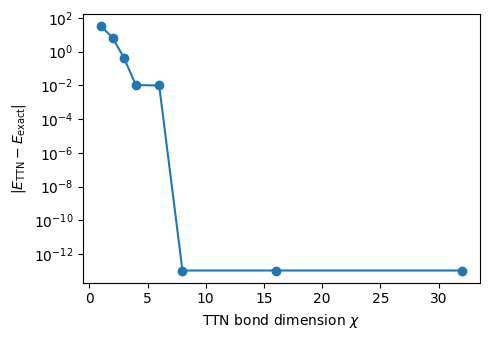

In [5]:
import matplotlib.pyplot as plt

# EfficientDepthOneEvaluator is analytically exact at p = 1, so it stands in for the
# statevector reference (which does not scale to the graph sizes used here).
exact_energy = EfficientDepthOneEvaluator().evaluate(cost_op, list(params))

bond_dimensions = [1, 2, 3, 4, 6, 8, 16, 32]
errors = [abs(ttn_causal_cone_evaluate(cost_op, params, chi) - exact_energy) for chi in bond_dimensions]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(bond_dimensions, np.maximum(errors, 1e-16), "o-")
ax.set_xlabel(r"TTN bond dimension $\chi$")
ax.set_ylabel(r"$|E_{\mathrm{TTN}} - E_{\mathrm{exact}}|$")
ax.set_yscale("log")
fig.tight_layout()

## Benchmark against the other evaluators

We now compare the TTN causal-cone evaluator against `MPSEvaluator`, `EfficientDepthOneEvaluator` and `LightConeEvaluator` on random regular graphs with a guaranteed large girth. Two constraints fix the experimental setup.

**Depth.** `EfficientDepthOneEvaluator` only exists at $p=1$, so the comparison runs at $p=1$. There it is *analytically exact*, which makes it the natural accuracy reference for the other three evaluators. Its own curve therefore sits on the clipping floor of the error panel by construction.

**Girth.** The depth-$p$ causal cone of an edge $(i,j)$ is the induced subgraph on $B_p(i)\cup B_p(j)$, so it is a tree exactly when the graph has no cycle short enough to fit inside that ball -- that is, when the girth is at least $2p+3$. For $p=1$ this means girth $\geq 5$. `networkx` ships `random_regular_graph`, but it gives no control over the girth: a random cubic graph almost always contains triangles and squares. Those instances are handled by the routing above, but routing is exactly what we do *not* want to fold into this first benchmark: it changes the gate count per edge, so it would confound the size scaling we are measuring here. The girth-constrained generator below isolates the pure tree-cone regime; the line-based instances further down are the counterpart, where every cone needs routing.

In [6]:
def random_regular_graph_min_girth(degree, num_nodes, min_girth, seed=None, max_restarts=500):
    """A random `degree`-regular graph on `num_nodes` nodes with girth at least `min_girth`.

    Built with the pairing model: half-edges ("stubs") are matched at random, but a pairing
    is rejected whenever it would close a cycle shorter than `min_girth`. A run that paints
    itself into a corner is restarted from scratch.
    """
    rng = np.random.default_rng(seed)
    for _ in range(max_restarts):
        graph = _attempt_min_girth_pairing(degree, num_nodes, min_girth, rng)
        if graph is not None:
            return graph

    raise RuntimeError(
        f"No {degree}-regular graph on {num_nodes} nodes with girth >= {min_girth} "
        f"found in {max_restarts} restarts."
    )


def _attempt_min_girth_pairing(degree, num_nodes, min_girth, rng, stall_limit=200):
    """One pairing-model attempt. Returns None if it gets stuck."""
    graph = nx.empty_graph(num_nodes)
    stubs = list(np.repeat(np.arange(num_nodes), degree))
    rng.shuffle(stubs)
    stalls = 0

    while stubs:
        idx1, idx2 = rng.choice(len(stubs), size=2, replace=False)
        node1, node2 = int(stubs[idx1]), int(stubs[idx2])

        # Adding (node1, node2) closes a cycle of length d(node1, node2) + 1, so the two
        # endpoints must already be at least `min_girth - 1` hops apart.
        too_close = nx.single_source_shortest_path_length(graph, node1, cutoff=min_girth - 2)
        if node1 == node2 or node2 in too_close:
            stalls += 1
            if stalls > stall_limit:
                return None
            continue

        graph.add_edge(node1, node2, weight=1.0)
        for idx in sorted((idx1, idx2), reverse=True):
            stubs.pop(idx)
        stalls = 0

    return graph


def all_cones_are_trees(graph, depth):
    """True if every edge's depth-`depth` reverse causal cone is a tree."""
    lce = LightConeEvaluator()
    lce.graph = graph
    return all(
        nx.is_tree(nx.Graph(list(lce.make_radius_edges(edge, radius=depth))))
        for edge in graph.edges
    )


DEGREE = 3                  # degree of the random regular graphs
DEPTH = 1                   # QAOA depth; EfficientDepthOneEvaluator only exists at p = 1
MIN_GIRTH = 2 * DEPTH + 3   # girth needed for every depth-p causal cone to be a tree

demo_graph = random_regular_graph_min_girth(DEGREE, 40, MIN_GIRTH, seed=0)
print(f"degree {DEGREE}, girth {nx.girth(demo_graph)} (need >= {MIN_GIRTH}), "
      f"every depth-{DEPTH} cone is a tree: {all_cones_are_trees(demo_graph, DEPTH)}")

degree 3, girth 5 (need >= 5), every depth-1 cone is a tree: True


In [7]:
GRAPH_SIZES = [10, 14, 20, 40, 60, 80]  # number of nodes; `DEGREE * n` must be even
NUM_INSTANCES = 3                       # random instances per size
BOND_DIM = 32                           # shared by the TTN and the MPS evaluator
BENCH_PARAMS = [0.4, 0.6]               # [beta_0, gamma_0], near the p=1 cubic-MaxCut optimum

# Evaluators are rebuilt for every measurement, so each timing includes its own setup cost
# and nothing is cached across instances.
BENCH_EVALUATORS = {
    "TTN causal cone": lambda op, prm: ttn_causal_cone_evaluate(op, prm, max_bond_dim=BOND_DIM),
    "MPS": lambda op, prm: MPSEvaluator(
        bond_dim_circuit=BOND_DIM, use_swap_strategy=True
    ).evaluate(op, prm),
    "EfficientDepthOne": lambda op, prm: EfficientDepthOneEvaluator().evaluate(op, prm),
    "LightCone": lambda op, prm: LightConeEvaluator().evaluate(op, prm),
}

records = []
for num_nodes in GRAPH_SIZES:
    for instance in range(NUM_INSTANCES):
        bench_graph = random_regular_graph_min_girth(
            DEGREE, num_nodes, MIN_GIRTH, seed=1000 * num_nodes + instance
        )
        bench_op = graph_to_operator(bench_graph, pre_factor=-0.5)  # MaxCut convention

        energies, runtimes = {}, {}
        for name, evaluate in BENCH_EVALUATORS.items():
            tic = time.perf_counter()
            energies[name] = float(evaluate(bench_op, BENCH_PARAMS))
            runtimes[name] = time.perf_counter() - tic

        # EfficientDepthOne is analytically exact at p = 1, so it is the accuracy reference.
        reference = energies["EfficientDepthOne"]
        records += [
            {
                "evaluator": name,
                "num_nodes": num_nodes,
                "instance": instance,
                "runtime": runtimes[name],
                "rel_error": abs(energies[name] - reference) / abs(reference),
            }
            for name in BENCH_EVALUATORS
        ]

        print(f"n={num_nodes:3d} instance={instance}  " + "  ".join(
            f"{name}: {runtimes[name]:7.2f}s" for name in BENCH_EVALUATORS), flush=True)

n= 10 instance=0  TTN causal cone:    0.08s  MPS:    0.22s  EfficientDepthOne:    0.00s  LightCone:    0.30s
n= 10 instance=1  TTN causal cone:    0.09s  MPS:    0.21s  EfficientDepthOne:    0.01s  LightCone:    0.27s
n= 10 instance=2  TTN causal cone:    0.09s  MPS:    0.11s  EfficientDepthOne:    0.01s  LightCone:    0.26s
n= 14 instance=0  TTN causal cone:    0.12s  MPS:    0.42s  EfficientDepthOne:    0.01s  LightCone:    0.40s
n= 14 instance=1  TTN causal cone:    0.11s  MPS:    0.43s  EfficientDepthOne:    0.01s  LightCone:    0.45s
n= 14 instance=2  TTN causal cone:    0.18s  MPS:    0.55s  EfficientDepthOne:    0.01s  LightCone:    0.41s
n= 20 instance=0  TTN causal cone:    0.18s  MPS:    1.24s  EfficientDepthOne:    0.01s  LightCone:    0.61s
n= 20 instance=1  TTN causal cone:    0.16s  MPS:    1.23s  EfficientDepthOne:    0.01s  LightCone:    0.52s
n= 20 instance=2  TTN causal cone:    0.16s  MPS:    1.02s  EfficientDepthOne:    0.01s  LightCone:    0.56s
n= 40 instance=0  T

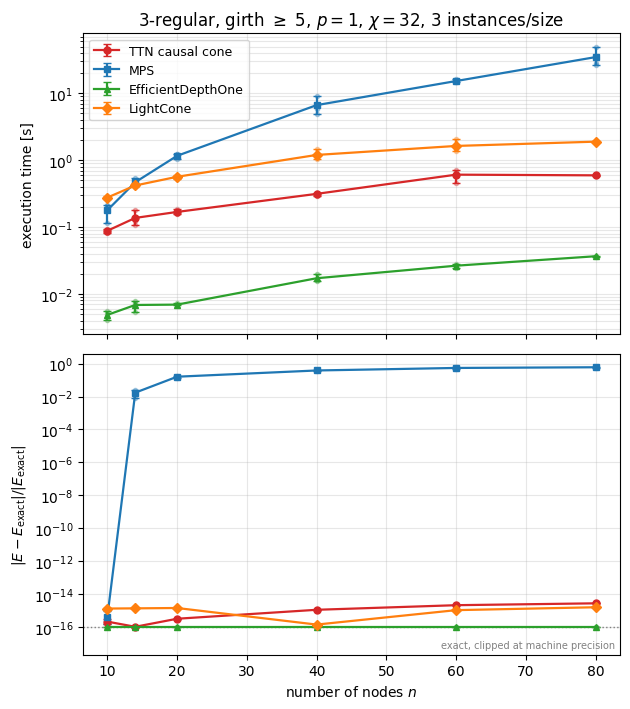

In [8]:
import matplotlib.pyplot as plt

STYLES = {
    "TTN causal cone": {"color": "tab:red", "marker": "o"},
    "MPS": {"color": "tab:blue", "marker": "s"},
    "EfficientDepthOne": {"color": "tab:green", "marker": "^"},
    "LightCone": {"color": "tab:orange", "marker": "D"},
}
FLOOR = 1e-16  # relative errors are clipped here so the exact evaluators stay on the log axis

fig, (ax_time, ax_error) = plt.subplots(2, 1, sharex=True, figsize=(6.4, 7.2))

for name, style in STYLES.items():
    rows = [r for r in records if r["evaluator"] == name]
    sizes = sorted({r["num_nodes"] for r in rows})
    runtimes = [[r["runtime"] for r in rows if r["num_nodes"] == n] for n in sizes]
    errors = [[max(r["rel_error"], FLOOR) for r in rows if r["num_nodes"] == n] for n in sizes]

    for axis, per_size in ((ax_time, runtimes), (ax_error, errors)):
        means = [np.mean(values) for values in per_size]
        # Clamped at zero: when an evaluator is exact, every instance of a size lands on the
        # same clipped value, and `np.mean` of identical floats can come out one ulp outside
        # [min, max] -- matplotlib then rejects the whole call over a -1e-17 error bar.
        low = [max(mean - np.min(values), 0.0) for mean, values in zip(means, per_size)]
        high = [max(np.max(values) - mean, 0.0) for mean, values in zip(means, per_size)]
        axis.errorbar(sizes, means, yerr=[low, high], label=name, capsize=3, lw=1.6, ms=5,
                      **style)
        # Individual instances, so the instance-to-instance spread stays visible.
        axis.scatter([n for n, values in zip(sizes, per_size) for _ in values],
                     [value for values in per_size for value in values],
                     s=9, alpha=0.35, zorder=1, color=style["color"])

ax_time.set_ylabel("execution time [s]")
ax_time.set_yscale("log")
ax_time.set_title(f"{DEGREE}-regular, girth $\\geq$ {MIN_GIRTH}, $p={DEPTH}$, "
                  f"$\\chi={BOND_DIM}$, {NUM_INSTANCES} instances/size")
ax_time.legend(fontsize=9, loc="upper left")

ax_error.set_ylabel(r"$|E - E_\mathrm{exact}| / |E_\mathrm{exact}|$")
ax_error.set_xlabel("number of nodes $n$")
ax_error.set_yscale("log")
ax_error.set_ylim(bottom=FLOOR / 50)  # room under the floor line for its label
ax_error.axhline(FLOOR, color="gray", ls=":", lw=1)
ax_error.text(0.99, 0.015, "exact, clipped at machine precision", fontsize=7, color="gray",
              transform=ax_error.transAxes, ha="right", va="bottom")

for axis in (ax_time, ax_error):
    axis.grid(alpha=0.3, which="both")

fig.tight_layout()

### Reading the plot

The two cone-based evaluators, `LightConeEvaluator` and the TTN, are exact to machine precision at every size: their cost per edge is set by the causal cone, which for a degree-$d$ graph at depth $p$ has a size independent of $n$, so both scale linearly in the number of edges. The TTN is consistently the cheaper of the two, because a cone that is a tree is contracted directly, whereas `LightConeEvaluator` builds, transpiles and statevector-simulates a Qiskit circuit per edge.

`MPSEvaluator` behaves very differently. At $n=10$ the bond dimension $\chi=32$ already saturates the maximum Schmidt rank $2^{n/2}$, so it is exact; beyond that it truncates, and because a random regular graph admits no one-dimensional ordering that keeps its cuts small, the relative error climbs steeply and does not level off -- about $2\%$ at $n=14$, $16\%$ at $n=20$, and $60\%$ by $n=80$. Its runtime grows steeply too, since the line swap strategy needs $O(n)$ layers of $O(n)$ gates, and the instance-to-instance spread at fixed $n$ is large: the bond dimension an instance actually reaches depends on how well the swap network happens to suit it.

`EfficientDepthOneEvaluator` is the fastest by an order of magnitude and is exact, but only because $p=1$ is precisely the case its closed-form density-matrix recursion covers. It is the right tool inside this plot and unavailable outside it, which is what makes the cone-based evaluators worth their extra cost: they carry over unchanged to $p\geq 2$, where the TTN's bond dimension becomes a real accuracy knob rather than a formality.

Two caveats when re-running this. The TTN error sits at the floor because a depth-1 cone on a cubic graph is only 6 qubits, far below $\chi=32$; to make the approximation actually bite, either lower `BOND_DIM`, or raise `DEPTH` -- `MIN_GIRTH` follows automatically, but you then have to drop `EfficientDepthOne` from `BENCH_EVALUATORS` and use `LightConeEvaluator` as the reference. And **`MPS` dominates the total runtime of the benchmark cell by a wide margin** -- with `GRAPH_SIZES` up to 80 it ran for over two hours on the machine these notes were written on, essentially all of it inside `MPSEvaluator` at $n \geq 60$ -- so shrink `GRAPH_SIZES` (or drop `MPS`) for a quicker pass.

## Line-based instances: cones that always need routing

The girth-constrained graphs above are the best case for a TTN: every cone is a tree and the routing code never fires. The opposite regime is the line-based instance family used in [`dmrg_qaoa.ipynb`](https://github.com/qiskit-community/qaoa-training-pipeline) (branch `dmrg_qaoa`): 100-node weighted MaxCut instances built by starting from a line graph and applying $s$ SWAP layers, which progressively densifies it ($s=0$ is the bare line, $s=N-2$ is fully connected). Weights are $\pm1$, so `min_cut` is not $0$ and the approximation ratio has to be normalized with both cuts.

We reuse the loading logic of that notebook verbatim: instances and pre-computed min/max cuts come from the companion **QAOA-Parameter-Setting** repository, and the angles come from `DepthOneScanTrainer` wrapped around the exact `EfficientDepthOneEvaluator` (for $p>1$, from the TQA results already stored in that repo, falling back to `FixedAngleConjecture`). Point `INSTANCE_DIR` at your clone.

This family is the interesting stress test here for two reasons:

* $s=0$ is a line, so *every* cone is a tree and the TTN is exact -- the control case.
* From $s=1$ on, the SWAP layers create triangles and squares, so at $p=1$ essentially every cone contains cycles. On the old statevector fallback, this whole family would have been evaluated by `LightConeEvaluator` and none of it by the TTN; with routing, it is TTN throughout, and $s$ becomes a dial for how much routing (and hence how much truncation error at fixed $\chi$) the evaluator has to absorb.

In [9]:
# Clone of the companion QAOA-Parameter-Setting repository; the default assumes it sits next
# to this repository.
INSTANCE_DIR = "../../QAOA-Parameter-Setting"

instance_dir = f"{INSTANCE_DIR}/instances/line_to_full"
cuts_dir = f"{INSTANCE_DIR}/data/minmax_cuts/line_to_full"
results_dir = f"{INSTANCE_DIR}/data/training/line_to_full"

LINE_DEPTH = 1                 # p = 1 keeps EfficientDepthOneEvaluator as an exact reference
SWAP_LAYER_COUNTS = [0, 2, 5]  # s = 0 is the bare line; larger s means denser cones
NUM_LINE_INSTANCES = 2         # instances per swap-layer group

# s = 10 also works -- 24-qubit cones with ~100 chords and ~280 SWAPs per layer and edge -- but
# costs minutes per instance and bond dimension, so it is left out of the default sweep.

depth_one_trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator(), num_points=15)


def get_params(cost_op, depth, k, idx):
    """Angles for one instance -- the loading logic of `how_tos/dmrg_qaoa.ipynb`, unchanged.

    Angles for depth 1 come from the (exact) depth-one scan. For depth > 1, first look for
    real, per-instance angles already computed in the companion repo under the "TQA"
    (Trotterized Quantum Annealing) trainer -- the only trainer with data for every one of our
    swap-layer groups at depth 2. If no such file exists for this (depth, k, idx), fall back to
    FixedAngleConjecture. That one requires an *exact* match to a (depth, integer degree) pair
    in its table, and not every degree has data at every depth, so we build a proxy regular
    graph with the closest degree that *is* available at this depth, just to retrieve the
    (graph-agnostic) angles.
    """
    if depth == 1:
        return depth_one_trainer.provide_params(cost_op)["optimized_qaoa_angles"]

    tqa_matches = glob.glob(f"{results_dir}/*{idx:03d}N100L2S{k}_MC_TQA_PP_*_{depth}.json")
    if tqa_matches:
        with open(tqa_matches[0]) as fh:
            return json.load(fh)["0"]["optimized_qaoa_angles"]

    trainer = FixedAngleConjecture(reps=depth)
    available_degrees = sorted({key[1] for key in trainer._data if key[0] == float(depth)})
    n_qubits = cost_op.num_qubits
    avg_degree = 2 * len(operator_to_list_of_hyper_edges(cost_op)) / n_qubits
    closest_degree = int(min(available_degrees, key=lambda d: abs(d - avg_degree)))
    proxy_graph = nx.random_regular_graph(closest_degree, n_qubits, seed=0)
    return trainer.provide_params(graph_to_operator(proxy_graph, pre_factor=-0.5))[
        "optimized_qaoa_angles"
    ]


line_groups = {}
for k in SWAP_LAYER_COUNTS:
    group = {"graphs": [], "cost_ops": [], "opt_angles": [],
             "max_cuts": [], "min_cuts": [], "sums_of_weights": []}

    for idx in range(NUM_LINE_INSTANCES):
        graph = load_graph(f"{instance_dir}/{idx:03d}_100nodes_{k}swap_layers.json")
        cost_op = graph_to_operator(graph, pre_factor=-0.5)  # standard MaxCut convention

        with open(f"{cuts_dir}/{idx:03d}_100nodes_{k}swap_layers_maxmin_cut.json") as fh:
            cut_info = json.load(fh)

        group["graphs"].append(graph)
        group["cost_ops"].append(cost_op)
        group["opt_angles"].append(get_params(cost_op, LINE_DEPTH, k, idx))
        group["max_cuts"].append(cut_info["max_cut"])
        group["min_cuts"].append(cut_info["min_cut"])
        group["sums_of_weights"].append(cut_info["sum_of_weights"])

    line_groups[k] = group

    # How much routing does this group imply? `num_chords == 0` for every edge means the whole
    # group is tree-cone and the SWAP machinery stays idle.
    stats = cone_routing_stats(group["graphs"][0], LINE_DEPTH)
    print(f"s={k:3d}: {len(stats)} edges, "
          f"cone qubits {np.mean([s['num_qubits'] for s in stats]):5.1f} avg / "
          f"{max(s['num_qubits'] for s in stats):3d} max, "
          f"chords {np.mean([s['num_chords'] for s in stats]):5.1f} avg / "
          f"{max(s['num_chords'] for s in stats):3d} max, "
          f"SWAPs/layer {np.mean([s['num_swaps'] for s in stats]):6.1f} avg / "
          f"{max(s['num_swaps'] for s in stats):3d} max, "
          f"angles {np.round(group['opt_angles'][0], 4)}", flush=True)

s=  0: 99 edges, cone qubits   4.0 avg /   4 max, chords   0.0 avg /   0 max, SWAPs/layer    0.0 avg /   0 max, angles [2.0196 0.8976]
s=  2: 198 edges, cone qubits   7.9 avg /   8 max, chords   4.0 avg /   6 max, SWAPs/layer   15.8 avg /  22 max, angles [1.122  5.8344]
s=  5: 346 edges, cone qubits  13.6 avg /  14 max, chords  19.9 avg /  28 max, SWAPs/layer   77.9 avg / 116 max, angles [0.4488 0.4488]


### Accuracy and runtime vs. bond dimension

For each swap-layer group we sweep $\chi$ for the routed TTN and for `MPSEvaluator`, and report

* the **approximation ratio** $(\mathrm{cut} - \mathrm{cut}_{\min}) / (\mathrm{cut}_{\max} - \mathrm{cut}_{\min})$, using the pre-computed cuts shipped with the instances (plain $\mathrm{cut}/\mathrm{cut}_{\max}$ would assume $\mathrm{cut}_{\min}=0$, which is false for these mixed-sign weights),
* the **relative energy error** against `EfficientDepthOneEvaluator`, which is analytically exact at $p=1$,
* the **runtime**.

`LightConeEvaluator` is included only while the cones stay small: it simulates one statevector per edge, so at $s=10$ its 24-qubit cones times ~600 edges is already impractical, which is precisely the regime the bounded-$\chi$ TTN is for.

In [10]:
LINE_BOND_DIMS = [2, 4, 8, 16]     # shared by the TTN and the MPS evaluator
LIGHT_CONE_QUBIT_LIMIT = 16        # above this cone size, one statevector per edge is too slow


def approximation_ratio(energy, sum_of_weights, min_cut, max_cut):
    """Normalized cut ratio, as in `how_tos/dmrg_qaoa.ipynb`."""
    cut_value = energy + 0.5 * sum_of_weights
    return (cut_value - min_cut) / (max_cut - min_cut)


line_records = []
for k, group in line_groups.items():
    max_cone_qubits = max(
        s["num_qubits"] for s in cone_routing_stats(group["graphs"][0], LINE_DEPTH)
    )

    measurements = [
        (name, chi, evaluate)
        for chi in LINE_BOND_DIMS
        for name, evaluate in (
            ("TTN causal cone", lambda op, prm, chi=chi: ttn_causal_cone_evaluate(op, prm, chi)),
            ("MPS", lambda op, prm, chi=chi: MPSEvaluator(
                bond_dim_circuit=chi, threshold_circuit=1e-14, use_swap_strategy=True
            ).evaluate(op, prm)),
        )
    ]
    if max_cone_qubits <= LIGHT_CONE_QUBIT_LIMIT:
        measurements.append(
            ("LightCone", None, lambda op, prm: LightConeEvaluator().evaluate(op, prm))
        )

    for idx in range(NUM_LINE_INSTANCES):
        cost_op, params = group["cost_ops"][idx], group["opt_angles"][idx]
        cuts = (group["sums_of_weights"][idx], group["min_cuts"][idx], group["max_cuts"][idx])

        # EfficientDepthOne is analytically exact at p = 1, so it is the accuracy reference.
        tic = time.perf_counter()
        exact = float(EfficientDepthOneEvaluator().evaluate(cost_op, params))
        exact_runtime = time.perf_counter() - tic

        for name, chi, evaluate in measurements + [
            ("EfficientDepthOne", None, lambda op, prm: exact)
        ]:
            tic = time.perf_counter()
            energy = float(evaluate(cost_op, params))
            runtime = exact_runtime if name == "EfficientDepthOne" else time.perf_counter() - tic

            line_records.append({
                "method": name,
                "chi": chi,
                "swap_layers": k,
                "instance": idx,
                "energy": energy,
                "runtime": runtime,
                "rel_error": abs(energy - exact) / abs(exact),
                "approx_ratio": approximation_ratio(energy, *cuts),
                "exact_approx_ratio": approximation_ratio(exact, *cuts),
            })

            label = f"{name}" + (f" (chi={chi})" if chi else "")
            print(f"s={k:3d} instance={idx}  {label:24s} E={energy:+11.5f}  "
                  f"AR={line_records[-1]['approx_ratio']:.4f}  "
                  f"rel={line_records[-1]['rel_error']:.2e}  {runtime:7.2f}s", flush=True)

s=  0 instance=0  TTN causal cone (chi=2)  E=  +23.66798  AR=0.7391  rel=1.20e-15     0.31s
s=  0 instance=0  MPS (chi=2)              E=  +23.66798  AR=0.7391  rel=2.85e-15     1.97s
s=  0 instance=0  TTN causal cone (chi=4)  E=  +23.66798  AR=0.7391  rel=1.20e-15     0.29s
s=  0 instance=0  MPS (chi=4)              E=  +23.66798  AR=0.7391  rel=2.85e-15     0.90s
s=  0 instance=0  TTN causal cone (chi=8)  E=  +23.66798  AR=0.7391  rel=1.20e-15     0.31s
s=  0 instance=0  MPS (chi=8)              E=  +23.66798  AR=0.7391  rel=2.85e-15     0.92s
s=  0 instance=0  TTN causal cone (chi=16) E=  +23.66798  AR=0.7391  rel=1.20e-15     0.28s
s=  0 instance=0  MPS (chi=16)             E=  +23.66798  AR=0.7391  rel=2.85e-15     0.88s
s=  0 instance=0  LightCone                E=  +23.66798  AR=0.7391  rel=6.00e-16     1.53s
s=  0 instance=0  EfficientDepthOne        E=  +23.66798  AR=0.7391  rel=0.00e+00     0.03s
s=  0 instance=1  TTN causal cone (chi=2)  E=  +23.66798  AR=0.7391  rel=1.35e-1

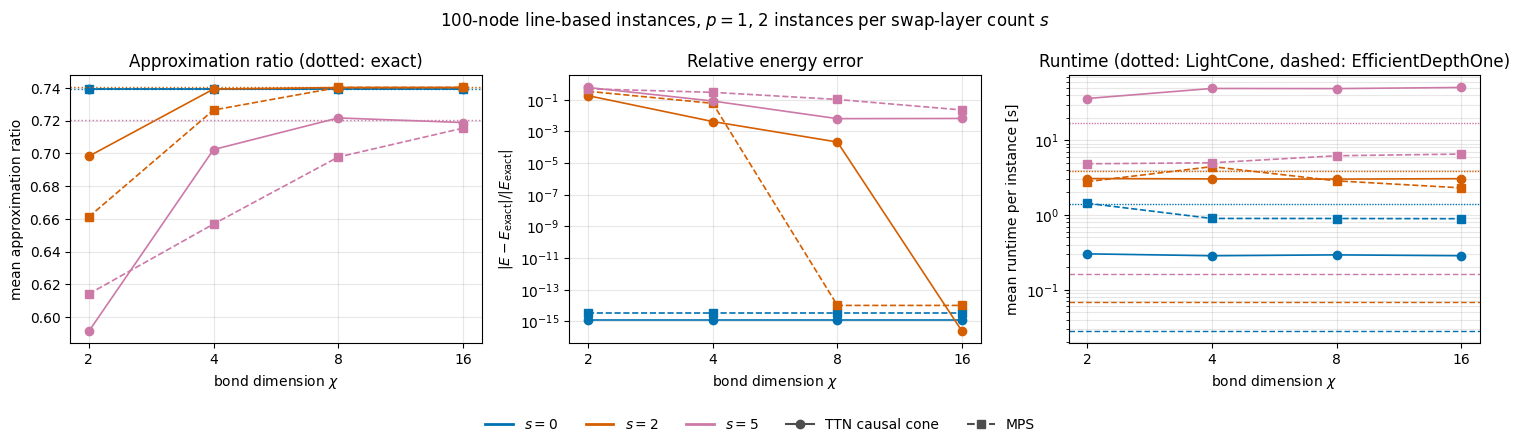

In [11]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SWAP_COLORS = {0: "#0072B2", 2: "#D55E00", 5: "#CC79A7", 10: "#009E73"}
METHOD_STYLES = {
    "TTN causal cone": {"marker": "o", "linestyle": "-"},
    "MPS": {"marker": "s", "linestyle": "--"},
}
ERROR_FLOOR = 1e-16  # exact evaluators would fall off a log axis otherwise


def mean_over_instances(method, k, chi, field):
    values = [r[field] for r in line_records
              if r["method"] == method and r["swap_layers"] == k and r["chi"] == chi]
    return np.mean(values) if values else np.nan


fig, (ax_ratio, ax_error, ax_time) = plt.subplots(1, 3, figsize=(15, 4.4))

for k in SWAP_LAYER_COUNTS:
    color = SWAP_COLORS.get(k, "0.4")

    for method, style in METHOD_STYLES.items():
        ratios = [mean_over_instances(method, k, chi, "approx_ratio") for chi in LINE_BOND_DIMS]
        errors = [max(mean_over_instances(method, k, chi, "rel_error"), ERROR_FLOOR)
                  for chi in LINE_BOND_DIMS]
        runtimes = [mean_over_instances(method, k, chi, "runtime") for chi in LINE_BOND_DIMS]

        for axis, values in ((ax_ratio, ratios), (ax_error, errors), (ax_time, runtimes)):
            axis.plot(LINE_BOND_DIMS, values, color=color, markersize=6, linewidth=1.2, **style)

    # chi-independent references: exact approximation ratio, and the runtime of the two exact
    # evaluators (LightCone is absent for the groups whose cones grew past the qubit limit).
    exact_ratio = np.mean([r["exact_approx_ratio"] for r in line_records if r["swap_layers"] == k])
    ax_ratio.axhline(exact_ratio, color=color, lw=1, ls=":")

    for method, dashes in (("LightCone", (1, 1)), ("EfficientDepthOne", (4, 2))):
        runtime = mean_over_instances(method, k, None, "runtime")
        if not np.isnan(runtime):
            ax_time.axhline(runtime, color=color, lw=1, dashes=dashes)

ax_ratio.set_ylabel("mean approximation ratio")
ax_ratio.set_title("Approximation ratio (dotted: exact)")
ax_error.set_ylabel(r"$|E - E_\mathrm{exact}| / |E_\mathrm{exact}|$")
ax_error.set_title("Relative energy error")
ax_error.set_yscale("log")
ax_time.set_ylabel("mean runtime per instance [s]")
ax_time.set_title("Runtime (dotted: LightCone, dashed: EfficientDepthOne)")
ax_time.set_yscale("log")

for axis in (ax_ratio, ax_error, ax_time):
    axis.set_xlabel(r"bond dimension $\chi$")
    axis.set_xscale("log", base=2)
    axis.set_xticks(LINE_BOND_DIMS, [str(chi) for chi in LINE_BOND_DIMS])
    axis.grid(alpha=0.3, which="both")

fig.legend(
    handles=[Line2D([0], [0], color=SWAP_COLORS.get(k, "0.4"), lw=2, label=f"$s={k}$")
             for k in SWAP_LAYER_COUNTS]
    + [Line2D([0], [0], color="0.3", label=name, markersize=6, **style)
       for name, style in METHOD_STYLES.items()],
    loc="lower center", ncol=len(SWAP_LAYER_COUNTS) + len(METHOD_STYLES), frameon=False,
)
fig.suptitle(f"100-node line-based instances, $p={LINE_DEPTH}$, "
             f"{NUM_LINE_INSTANCES} instances per swap-layer count $s$")
fig.tight_layout(rect=(0, 0.08, 1, 1))